In [1]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

In [2]:
df = pd.read_csv(r'../data/raw/woe_encoded.csv')
print(df.head())

   laufkont_woe  moral_woe  sparkont_woe  verw_woe  verm_woe  laufzeit_woe  \
0      0.818099  -0.733741      0.271358  0.095557  0.028573      0.331832   
1      0.818099  -0.733741      0.271358  0.359200 -0.461035     -0.753772   
2      0.401392   0.088319      0.139552  0.230524 -0.461035     -0.301325   
3      0.818099  -0.733741      0.271358  0.359200 -0.461035     -0.301325   
4      0.818099  -0.733741      0.271358  0.359200  0.028573     -0.301325   

   hoehe_woe  alter_woe  kredit  
0  -0.014185   0.441833       1  
1  -0.305382  -0.517018       1  
2   0.047179   0.441833       1  
3   0.000000  -0.287682       1  
4   0.000000  -0.287682       1  


In [3]:
# Logistic fit

# variables
X=df.drop(columns='kredit')
y=df['kredit']

print(X.shape)
print(y.value_counts())

print('='*70)
#split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                      test_size=0.2, 
                                                      random_state=42,
                                                      stratify=y)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.3f}")
print(f"Test default rate: {y_test.mean():.3f}")

# model
model = LogisticRegression()
model.fit(X_train, y_train)

#pred
y_pred = model.predict(X_test)

#metrcis
y_pred_proba = model.predict_proba(X_test)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(classification_report(y_test, y_pred))


(1000, 8)
kredit
1    700
0    300
Name: count, dtype: int64
Train: (800, 8), Test: (200, 8)
Train default rate: 0.700
Test default rate: 0.700
ROC-AUC: 0.8176
              precision    recall  f1-score   support

           0       0.64      0.47      0.54        60
           1       0.79      0.89      0.84       140

    accuracy                           0.76       200
   macro avg       0.72      0.68      0.69       200
weighted avg       0.75      0.76      0.75       200



In [4]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.480557
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 kredit   No. Observations:                  800
Model:                          Logit   Df Residuals:                      791
Method:                           MLE   Df Model:                            8
Date:                Sat, 11 Apr 2026   Pseudo R-squ.:                  0.2133
Time:                        12:57:47   Log-Likelihood:                -384.45
converged:                       True   LL-Null:                       -488.69
Covariance Type:            nonrobust   LLR p-value:                 1.036e-40
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.8452      0.092      9.228      0.000       0.666       1.025
laufkont_woe    -0.7378

In [5]:
# update feature list - drop verm_woe
X_train_f = X_train.drop(columns='verm_woe')
X_test_f = X_test.drop(columns='verm_woe')

# sklearn
model = LogisticRegression()
model.fit(X_train_f, y_train)
y_pred = model.predict(X_test_f)
y_pred_proba = model.predict_proba(X_test_f)[:, 1]
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(classification_report(y_test, y_pred))

# statsmodels
X_train_sm = sm.add_constant(X_train_f)
result = sm.Logit(y_train, X_train_sm).fit()
print(result.summary())

ROC-AUC: 0.8115
              precision    recall  f1-score   support

           0       0.66      0.45      0.53        60
           1       0.79      0.90      0.84       140

    accuracy                           0.77       200
   macro avg       0.73      0.68      0.69       200
weighted avg       0.75      0.77      0.75       200

Optimization terminated successfully.
         Current function value: 0.482326
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 kredit   No. Observations:                  800
Model:                          Logit   Df Residuals:                      792
Method:                           MLE   Df Model:                            7
Date:                Sat, 11 Apr 2026   Pseudo R-squ.:                  0.2104
Time:                        12:57:47   Log-Likelihood:                -385.86
converged:                       True   LL-Null:                       -488.69
Co

In [6]:
params = result.params
print(params)

print(params.index)

const           0.850987
laufkont_woe   -0.748485
moral_woe      -0.740040
sparkont_woe   -0.929254
verw_woe       -1.035389
laufzeit_woe   -0.951700
hoehe_woe      -0.538669
alter_woe      -0.692691
dtype: float64
Index(['const', 'laufkont_woe', 'moral_woe', 'sparkont_woe', 'verw_woe',
       'laufzeit_woe', 'hoehe_woe', 'alter_woe'],
      dtype='object')


In [7]:
import numpy as np
# Points to Double the Odds parameters
base_score= 600
pdo = 20
base_odds = 2 

# Scalling constants

B = pdo/np.log(2)
A = base_score - B * np.log(base_odds)

print(f'B: {B:.4f}')
print(f'A: {A:.4f}')
print('='*70)
## calculating base points
base_points = A + B * params['const']
print(f"Base points: {base_points:.2f}")

print('='*70)

for i in params.index:
    if i == 'const':
        continue
    df[f'{i}_points']=B * params[i] * df[i]
point_cols=[col for col in df.columns if 'points' in col]

# Total score per applicant
df['score'] = base_points + df[point_cols].sum(axis=1)

print(df['score'].describe().round())

B: 28.8539
A: 580.0000
Base points: 604.55
count    1000.0
mean      613.0
std        40.0
min       504.0
25%       584.0
50%       613.0
75%       642.0
max       715.0
Name: score, dtype: float64


In [8]:
print(df.groupby('kredit')['score'].mean().round(2))

kredit
0    584.36
1    625.94
Name: score, dtype: float64


# Metrics

In [9]:
## Kolmogorov Smirnov
from scipy import stats

good_scores = df[df['kredit'] == 1]['score']
bad_scores = df[df['kredit'] == 0]['score']

ks_stat, p_value = stats.ks_2samp(good_scores, bad_scores)
print(f"KS Statistic: {ks_stat:.4f}")
print(f"P-value: {p_value:.4f}")

print('='*70)

## Gini
AUC = roc_auc_score(y_test, y_pred_proba)
Gini = 2 * AUC - 1
print(f"AUC: {AUC:.4f}")
print(f"Gini: {Gini:.4f}")


KS Statistic: 0.5100
P-value: 0.0000
AUC: 0.8115
Gini: 0.6231


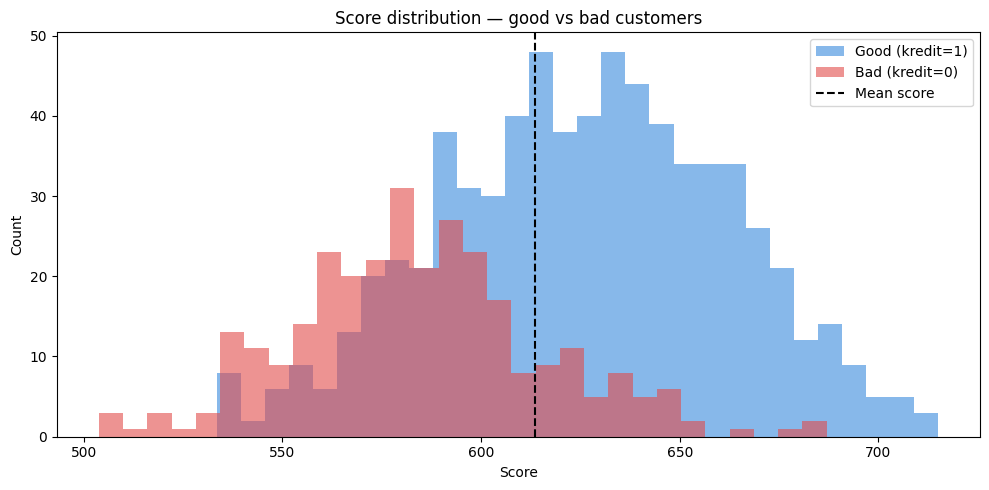

In [10]:
## Visualization
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(good_scores, bins=30, alpha=0.6, color='#378ADD', label='Good (kredit=1)')
ax.hist(bad_scores, bins=30, alpha=0.6, color='#E24B4A', label='Bad (kredit=0)')
ax.axvline(df['score'].mean(), color='black', linestyle='--', label='Mean score')
ax.set_xlabel('Score')
ax.set_ylabel('Count')
ax.set_title('Score distribution — good vs bad customers')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/score_distribution.png', dpi=150)
plt.show()

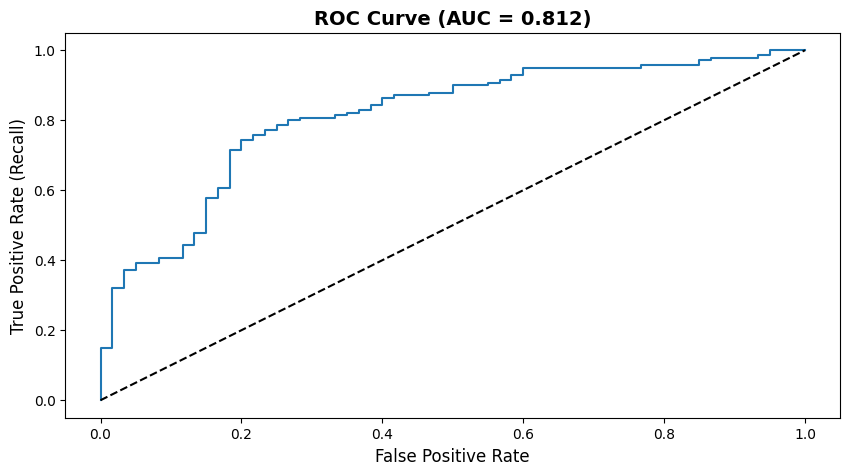

In [11]:
from sklearn.metrics import roc_curve

#Probabilities of the model
y_prob= model.predict_proba(X_test_f)[:, 1]


# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)


#Plot
plt.figure(figsize=(10,5))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], 'k--') #Random Classifier line
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title(f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.3f})', fontsize=14, fontweight='bold')
plt.savefig('../outputs/figures/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()